# Dataset Analysis

## Objective

Analyze the processed dataset to understand class distribution, feature relationships, and data characteristics that may influence model performance.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_classif

import warnings
warnings.filterwarnings("ignore")

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

class
0    9337
1    9604
2    7540
Name: count, dtype: int64


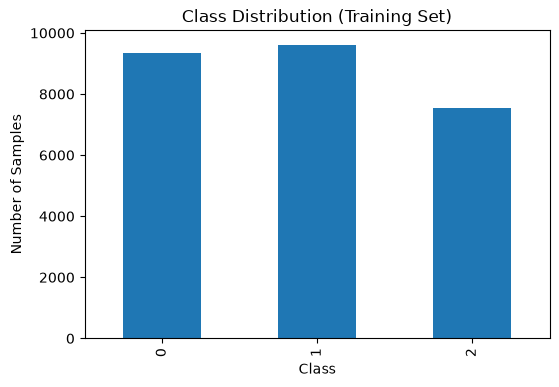

In [3]:
class_counts = y_train.value_counts().sort_index()

print(class_counts)

plt.figure(figsize=(6,4))
class_counts.plot(kind="bar")

plt.title("Class Distribution (Training Set)")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.show()

In [4]:
corr_matrix = X_train.corr()

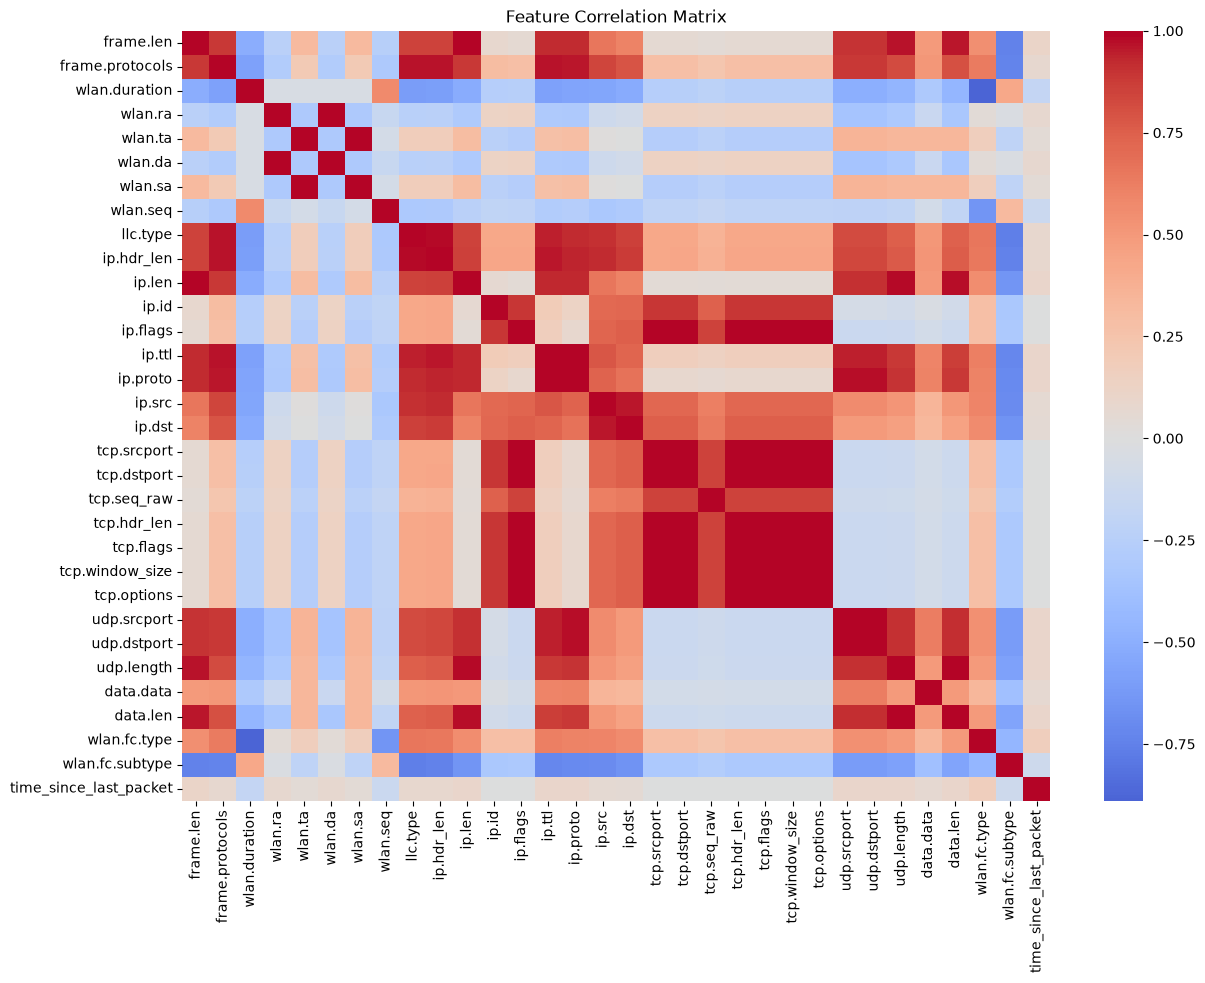

In [5]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")

plt.show()

In [6]:
corr_pairs = (
    corr_matrix.abs()
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
)

high_corr = (
    corr_pairs.stack()
    .reset_index()
)

high_corr.columns = ["Feature 1", "Feature 2", "Correlation"]

high_corr = high_corr[
    high_corr["Correlation"] > 0.90
].sort_values(
    by="Correlation",
    ascending=False
)

high_corr

,Feature 1,Feature 2,Correlation
101,wlan.ra,wlan.da,1.000000
134,wlan.ta,wlan.sa,1.000000
661,tcp.hdr_len,tcp.flags,1.000000
727,tcp.window_size,tcp.options,1.000000
695,tcp.flags,tcp.options,1.000000
694,tcp.flags,tcp.window_size,1.000000
663,tcp.hdr_len,tcp.options,1.000000
662,tcp.hdr_len,tcp.window_size,1.000000
598,tcp.dstport,tcp.window_size,1.000000
599,tcp.dstport,tcp.options,1.000000
